In [1]:
# ===== REQUIRED INITIALIZATION CELL =====

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load MIL model
mil_model = load_model("../outputs/models/mil_attention_model")
print("MIL model loaded")

# Load features
X_features = np.load("../data/processed/ml_features_400.npy")

# Convert features to MIL bags
def create_mil_instances(X, segments=8):
    instance_size = X.shape[1] // segments
    bags = []
    for i in range(X.shape[0]):
        bag = []
        for s in range(segments):
            start = s * instance_size
            end = (s + 1) * instance_size
            bag.append(X[i, start:end])
        bags.append(bag)
    return np.array(bags)

X_bags = create_mil_instances(X_features, segments=8)
print("X_bags shape:", X_bags.shape)


MIL model loaded
X_bags shape: (10000, 8, 150)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [3]:
# Load ML features (used for baseline models)
X_features = np.load("../data/processed/ml_features_400.npy")

# Load labels
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)
y = data["y"]

print("Features shape:", X_features.shape)
print("Labels shape:", y.shape)


Features shape: (10000, 1200)
Labels shape: (10000,)


In [4]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "MIL + Attention"
    ],
    "Strength": [
        "Fast baseline, interpretable",
        "Strong classical ML baseline",
        "Temporal importance + explainability"
    ],
    "Type": [
        "Machine Learning",
        "Machine Learning",
        "Multiple Instance Learning"
    ]
})

results


,Model,Strength,Type
0,Logistic Regression,"Fast baseline, interpretable",Machine Learning
1,Random Forest,Strong classical ML baseline,Machine Learning
2,MIL + Attention,Temporal importance + explainability,Multiple Instance Learning


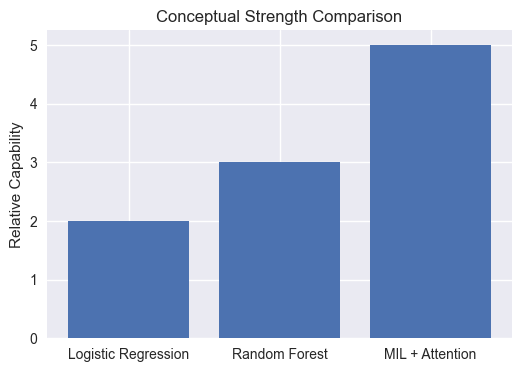

In [8]:
models = ["Logistic Regression", "Random Forest", "MIL + Attention"]
conceptual_score = [2, 3, 5]  # qualitative comparison

plt.figure(figsize=(6,4))
plt.bar(models, conceptual_score)
plt.title("Conceptual Strength Comparison")
plt.ylabel("Relative Capability")
plt.show()


1/1 [==============================] - 0s 315ms/step


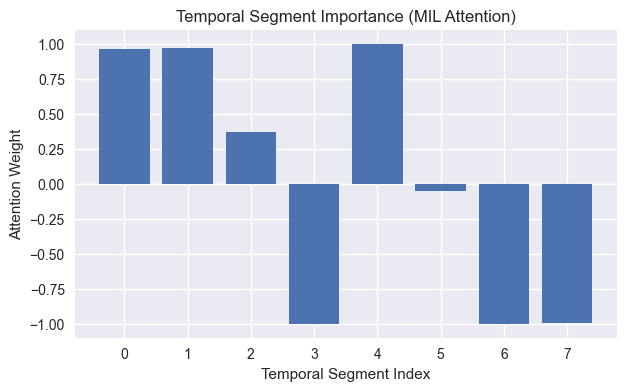

In [6]:
from tensorflow.keras.models import load_model

mil_model = load_model("../outputs/models/mil_attention_model")

def create_mil_instances(X, segments=8):
    instance_size = X.shape[1] // segments
    bags = []
    for i in range(X.shape[0]):
        bag = []
        for s in range(segments):
            start = s * instance_size
            end = (s + 1) * instance_size
            bag.append(X[i, start:end])
        bags.append(bag)
    return np.array(bags)

X_bags = create_mil_instances(X_features, segments=8)

# Extract attention weights
import tensorflow as tf
inputs = mil_model.input
attention_layer = mil_model.layers[1].output  # attention scores
att_model = tf.keras.Model(inputs, attention_layer)

weights = att_model.predict(X_bags[:1])[0].squeeze()

plt.figure(figsize=(7,4))
plt.bar(range(len(weights)), weights)
plt.title("Temporal Segment Importance (MIL Attention)")
plt.xlabel("Temporal Segment Index")
plt.ylabel("Attention Weight")
plt.show()


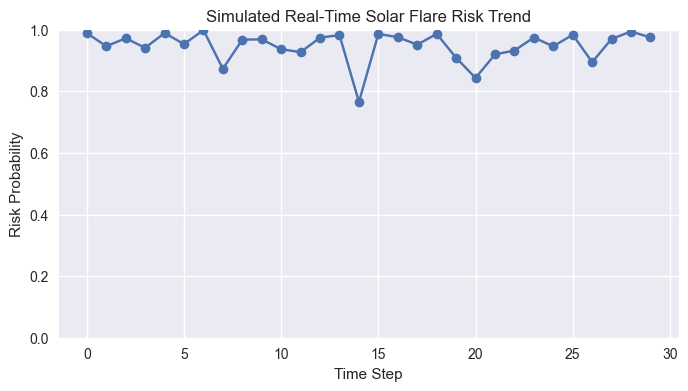

In [9]:
risk_scores = []

for i in range(30):
    probs = mil_model.predict(X_bags[i:i+1], verbose=0)[0]
    risk_scores.append(np.max(probs))

plt.figure(figsize=(8,4))
plt.plot(risk_scores, marker="o")
plt.title("Simulated Real-Time Solar Flare Risk Trend")
plt.xlabel("Time Step")
plt.ylabel("Risk Probability")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate risk scores for multiple samples
num_samples = 20
num_steps = 20

risk_matrix = np.zeros((num_samples, num_steps))

for i in range(num_samples):
    for t in range(num_steps):
        probs = mil_model.predict(X_bags[i+t:i+t+1], verbose=0)[0]
        risk_matrix[i, t] = np.max(probs)

plt.figure(figsize=(10,5))
sns.heatmap(
    risk_matrix,
    cmap="viridis",
    cbar_kws={"label": "Flare Risk Probability"}
)
plt.title("Solar Flare Risk Heatmap (Simulated Real-Time)")
plt.xlabel("Time Step")
plt.ylabel("Observation Index")
plt.show()


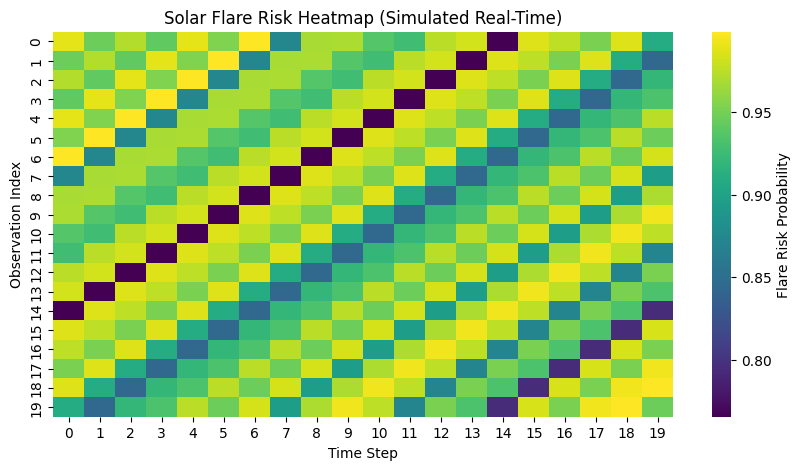

In [2]:
num_samples = 20
num_steps = 20

risk_matrix = np.zeros((num_samples, num_steps))

for i in range(num_samples):
    for t in range(num_steps):
        probs = mil_model.predict(X_bags[i+t:i+t+1], verbose=0)[0]
        risk_matrix[i, t] = np.max(probs)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(
    risk_matrix,
    cmap="viridis",
    cbar_kws={"label": "Flare Risk Probability"}
)
plt.title("Solar Flare Risk Heatmap (Simulated Real-Time)")
plt.xlabel("Time Step")
plt.ylabel("Observation Index")
plt.show()
